# 04 - Mixture of Experts

This notebook compares a single baseline model against a regime-aware Mixture of Experts (MoE).

Input: `../data/processed/regime_features.csv`  
Output: model comparison metrics and prediction CSV files.

## What We Are Doing

In notebook 03, the HMM discovered market regimes: Bull, Bear, and Crisis.

Now we test the main research idea:

> A single model treats all markets as one environment. A Mixture of Experts trains different models for different regimes.

We compare:

- **Baseline model**: one model trained on all data
- **Expert models**: one model per regime
- **Gating mechanism**: HMM regime probabilities decide how much to trust each expert

## 1. Imports

Important terms:

- **Random Forest**: an ensemble ML model made from many decision trees.
- **RMSE**: prediction error for returns. Lower is better.
- **Direction Accuracy**: how often the model predicts up/down correctly.
- **Sharpe Ratio**: return per unit of risk. Higher is better.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Load Regime Dataset

This file was created by notebook 03. It contains market features plus HMM regime labels and regime probabilities.

In [3]:
DATA_PATH = Path("../data/processed/regime_features.csv")
OUTPUT_DIR = Path("../data/processed")

regime_df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
regime_df = regime_df.sort_values("Date").reset_index(drop=True)

print(regime_df.shape)
print(regime_df["regime_label"].value_counts())
regime_df.head()

(623, 17)
regime_label
Bear      412
Bull      118
Crisis     93
Name: count, dtype: int64


,Date,ticker,Close,return_1d,volatility_30d,momentum_30d,ma_50_ratio,ma_200_ratio,drawdown,vix_close,target_return_1d,target_direction_1d,regime,regime_label,regime_0_prob,regime_1_prob,regime_2_prob
0,2010-04-27,^GSPC,1183.709961,-0.023382,0.007319,0.028857,0.020765,NaN,-0.027578,22.809999,0.006463,1,1,Bull,5.500702e-12,1.000000,1.553645e-11
1,2010-04-28,^GSPC,1191.359985,0.006463,0.007280,0.027513,0.025655,NaN,-0.021293,21.080000,0.012943,1,0,Bear,9.833277e-01,0.016623,4.970221e-05
2,2010-04-29,^GSPC,1206.780029,0.012943,0.007556,0.034788,0.037015,NaN,-0.008626,18.440001,-0.016648,0,0,Bear,9.994668e-01,0.000531,1.791272e-06
3,2010-04-30,^GSPC,1186.689941,-0.016648,0.008225,0.017893,0.018352,NaN,-0.025130,22.049999,0.013121,1,0,Bear,9.998941e-01,0.000065,4.078930e-05
4,2010-05-03,^GSPC,1202.260010,0.013121,0.008458,0.036520,0.030068,NaN,-0.012339,20.190001,-0.023838,0,0,Bear,9.986716e-01,0.000053,1.275341e-03


## 3. Choose Features And Target

Target:

- `target_return_1d`: tomorrow's return

Features:

- return, volatility, momentum, drawdown, VIX, and regime probabilities

We do not use `target_direction_1d` as an input because it is also future information.

In [4]:
feature_cols = [
    "return_1d",
    "volatility_30d",
    "momentum_30d",
    "ma_50_ratio",
    "drawdown",
    "vix_close",
    "regime_0_prob",
    "regime_1_prob",
    "regime_2_prob",
]

target_col = "target_return_1d"

data = regime_df.dropna(subset=feature_cols + [target_col, "regime_label"]).copy()

data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

print(data.shape)
data[["Date", "ticker", "Close", "regime_label"] + feature_cols + [target_col]].head()

(623, 17)


,Date,ticker,Close,regime_label,return_1d,volatility_30d,momentum_30d,ma_50_ratio,drawdown,vix_close,regime_0_prob,regime_1_prob,regime_2_prob,target_return_1d
0,2010-04-27,^GSPC,1183.709961,Bull,-0.023382,0.007319,0.028857,0.020765,-0.027578,22.809999,5.500702e-12,1.000000,1.553645e-11,0.006463
1,2010-04-28,^GSPC,1191.359985,Bear,0.006463,0.007280,0.027513,0.025655,-0.021293,21.080000,9.833277e-01,0.016623,4.970221e-05,0.012943
2,2010-04-29,^GSPC,1206.780029,Bear,0.012943,0.007556,0.034788,0.037015,-0.008626,18.440001,9.994668e-01,0.000531,1.791272e-06,-0.016648
3,2010-04-30,^GSPC,1186.689941,Bear,-0.016648,0.008225,0.017893,0.018352,-0.025130,22.049999,9.998941e-01,0.000065,4.078930e-05,0.013121
4,2010-05-03,^GSPC,1202.260010,Bear,0.013121,0.008458,0.036520,0.030068,-0.012339,20.190001,9.986716e-01,0.000053,1.275341e-03,-0.023838


## 4. Time-Based Train/Test Split

Financial data must be split by time, not randomly.

Why? Random splitting leaks future market information into the past.

We use the first 80% for training and the last 20% for testing.

In [5]:
split_idx = int(len(data) * 0.8)

train_df = data.iloc[:split_idx].copy()
test_df = data.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train period:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Test period:", test_df["Date"].min(), "to", test_df["Date"].max())
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train period: 2010-04-27 00:00:00 to 2021-05-17 00:00:00
Test period: 2021-05-18 00:00:00 to 2025-11-25 00:00:00
Train rows: 498
Test rows: 125


## 5. Evaluation Functions

We evaluate both prediction quality and trading usefulness.

Important terms:

- **Predicted return**: model's estimate of tomorrow's return.
- **Direction prediction**: positive return = up, negative return = down.
- **Strategy return**: if prediction is positive, stay long; if negative, stay out of market.

In [6]:
def calculate_direction_accuracy(y_true, y_pred):
    true_direction = (np.asarray(y_true) > 0).astype(int)
    pred_direction = (np.asarray(y_pred) > 0).astype(int)
    return accuracy_score(true_direction, pred_direction)


def calculate_strategy_returns(y_true, y_pred):
    signal = (np.asarray(y_pred) > 0).astype(int)
    return signal * np.asarray(y_true)


def annualized_sharpe(returns, periods_per_year=252):
    returns = pd.Series(returns).dropna()
    if returns.std() == 0:
        return 0
    return (returns.mean() / returns.std()) * np.sqrt(periods_per_year)


def max_drawdown(returns):
    returns = pd.Series(returns).fillna(0)
    equity_curve = (1 + returns).cumprod()
    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1
    return drawdown.min()


def evaluate_predictions(name, y_true, y_pred):
    strategy_returns = calculate_strategy_returns(y_true, y_pred)
    buy_hold_returns = np.asarray(y_true)

    return {
        "model": name,
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "direction_accuracy": calculate_direction_accuracy(y_true, y_pred),
        "strategy_sharpe": annualized_sharpe(strategy_returns),
        "strategy_max_drawdown": max_drawdown(strategy_returns),
        "buy_hold_sharpe": annualized_sharpe(buy_hold_returns),
        "buy_hold_max_drawdown": max_drawdown(buy_hold_returns),
    }

## 6. Baseline Model

The baseline is one model trained on all training data, regardless of regime.

This is what we want to beat.

In [7]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1,
    ))
])

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_metrics = evaluate_predictions("Baseline Random Forest", y_test, baseline_pred)
baseline_metrics

{'model': 'Baseline Random Forest',
 'rmse': np.float64(0.010910544921031143),
 'mae': 0.007828183466607049,
 'direction_accuracy': 0.536,
 'strategy_sharpe': np.float64(2.161004345102019),
 'strategy_max_drawdown': np.float64(-0.0928753723849024),
 'buy_hold_sharpe': np.float64(2.2508146088340406),
 'buy_hold_max_drawdown': np.float64(-0.09287537238490251)}

## 7. Train Expert Models By Regime

Each expert specializes in one HMM regime.

Example:

- Bull Expert trains mostly on Bull data
- Bear Expert trains mostly on Bear data
- Crisis Expert trains mostly on Crisis data

If a regime has too few rows, we fall back to the baseline model for that expert.

In [8]:
expert_models = {}
min_rows_per_expert = 50

for regime_label in sorted(train_df["regime_label"].unique()):
    regime_train = train_df[train_df["regime_label"] == regime_label].copy()

    print(regime_label, "training rows:", len(regime_train))

    if len(regime_train) < min_rows_per_expert:
        expert_models[regime_label] = baseline_model
        print(f"Using baseline fallback for {regime_label}")
        continue

    expert = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=4,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        ))
    ])

    expert.fit(regime_train[feature_cols], regime_train[target_col])
    expert_models[regime_label] = expert

expert_models.keys()

Bear training rows: 355
Bull training rows: 82
Crisis training rows: 61


dict_keys(['Bear', 'Bull', 'Crisis'])

## 8. Hard Regime Routing

Hard routing means:

> Use only the expert assigned to the current regime.

If today is Bull, use Bull Expert. If today is Crisis, use Crisis Expert.

In [9]:
hard_moe_pred = np.zeros(len(test_df))

for i, row in test_df.reset_index(drop=True).iterrows():
    regime_label = row["regime_label"]
    expert = expert_models[regime_label]
    x_row = pd.DataFrame([row[feature_cols].values], columns=feature_cols)
    hard_moe_pred[i] = expert.predict(x_row)[0]

hard_moe_metrics = evaluate_predictions("Hard-Routed MoE", y_test, hard_moe_pred)
hard_moe_metrics

{'model': 'Hard-Routed MoE',
 'rmse': np.float64(0.011232276163357497),
 'mae': 0.008100235290433588,
 'direction_accuracy': 0.512,
 'strategy_sharpe': np.float64(1.9422517035085378),
 'strategy_max_drawdown': np.float64(-0.09287537238490251),
 'buy_hold_sharpe': np.float64(2.2508146088340406),
 'buy_hold_max_drawdown': np.float64(-0.09287537238490251)}

## 9. Soft Gating MoE

Soft gating is closer to true Mixture of Experts.

Instead of choosing only one expert, we combine predictions using HMM regime probabilities.

Example:

```text
Final prediction =
0.70 * Bull Expert
+ 0.20 * Bear Expert
+ 0.10 * Crisis Expert
```

In [10]:
regime_to_state = (
    train_df[["regime", "regime_label"]]
    .drop_duplicates()
    .set_index("regime_label")["regime"]
    .to_dict()
)

print(regime_to_state)

soft_moe_pred = np.zeros(len(test_df))

test_reset = test_df.reset_index(drop=True)

for i, row in test_reset.iterrows():
    weighted_prediction = 0
    total_weight = 0

    for regime_label, expert in expert_models.items():
        state_number = regime_to_state[regime_label]
        prob_col = f"regime_{state_number}_prob"
        weight = row[prob_col]

        x_row = pd.DataFrame([row[feature_cols].values], columns=feature_cols)
        expert_pred = expert.predict(x_row)[0]

        weighted_prediction += weight * expert_pred
        total_weight += weight

    soft_moe_pred[i] = weighted_prediction / total_weight if total_weight > 0 else baseline_pred[i]

soft_moe_metrics = evaluate_predictions("Soft-Gated MoE", y_test, soft_moe_pred)
soft_moe_metrics

{'Bull': 1, 'Bear': 0, 'Crisis': 2}


{'model': 'Soft-Gated MoE',
 'rmse': np.float64(0.011232263153453496),
 'mae': 0.008100190819436639,
 'direction_accuracy': 0.512,
 'strategy_sharpe': np.float64(1.9422517035085378),
 'strategy_max_drawdown': np.float64(-0.09287537238490251),
 'buy_hold_sharpe': np.float64(2.2508146088340406),
 'buy_hold_max_drawdown': np.float64(-0.09287537238490251)}

## 10. Compare Models

This is the key result table for the project.

In [11]:
metrics_df = pd.DataFrame([
    baseline_metrics,
    hard_moe_metrics,
    soft_moe_metrics,
])

metrics_df = metrics_df.sort_values("direction_accuracy", ascending=False).reset_index(drop=True)
metrics_df

,model,rmse,mae,direction_accuracy,strategy_sharpe,strategy_max_drawdown,buy_hold_sharpe,buy_hold_max_drawdown
0,Baseline Random Forest,0.010911,0.007828,0.536,2.161004,-0.092875,2.250815,-0.092875
1,Hard-Routed MoE,0.011232,0.008100,0.512,1.942252,-0.092875,2.250815,-0.092875
2,Soft-Gated MoE,0.011232,0.008100,0.512,1.942252,-0.092875,2.250815,-0.092875


In [12]:
metrics_df.to_csv(OUTPUT_DIR / "model_comparison_metrics.csv", index=False)
print("Saved metrics to:", OUTPUT_DIR / "model_comparison_metrics.csv")

Saved metrics to: ..\data\processed\model_comparison_metrics.csv


## 11. Visualize Predictions

We compare actual returns and predicted returns over the test period.

In [13]:
predictions_df = test_df[["Date", "ticker", "Close", "regime_label", target_col]].copy()
predictions_df["baseline_pred"] = baseline_pred
predictions_df["hard_moe_pred"] = hard_moe_pred
predictions_df["soft_moe_pred"] = soft_moe_pred

predictions_df.to_csv(OUTPUT_DIR / "moe_predictions.csv", index=False)
print("Saved predictions to:", OUTPUT_DIR / "moe_predictions.csv")

predictions_df.head()

Saved predictions to: ..\data\processed\moe_predictions.csv


,Date,ticker,Close,regime_label,target_return_1d,baseline_pred,hard_moe_pred,soft_moe_pred
498,2021-05-18,^GSPC,4127.830078,Bear,-0.002943,0.000296,-0.000385,-0.000385
499,2021-05-19,^GSPC,4115.680176,Bear,0.010555,0.000610,0.000727,0.000727
500,2021-05-20,^GSPC,4159.120117,Bear,-0.000784,0.000352,0.000925,0.000925
501,2021-05-21,^GSPC,4155.859863,Bear,0.009911,-0.000275,-0.000731,-0.000731
502,2021-05-24,^GSPC,4197.049805,Bear,-0.002125,-0.001167,-0.002338,-0.002338


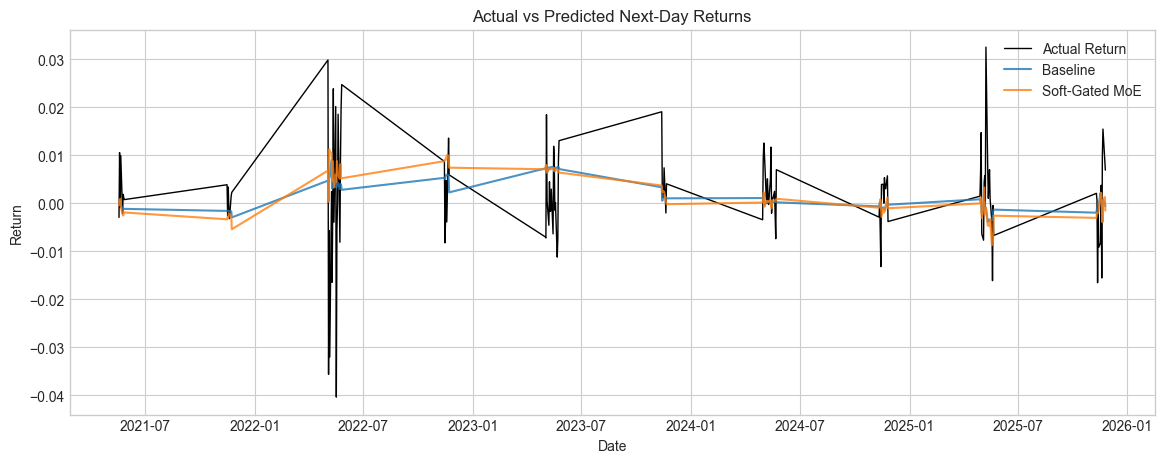

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(predictions_df["Date"], predictions_df[target_col], label="Actual Return", color="black", linewidth=1)
plt.plot(predictions_df["Date"], predictions_df["baseline_pred"], label="Baseline", alpha=0.8)
plt.plot(predictions_df["Date"], predictions_df["soft_moe_pred"], label="Soft-Gated MoE", alpha=0.8)
plt.title("Actual vs Predicted Next-Day Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()

## 12. Strategy Equity Curves

This is not a full trading system. It is a simple research evaluation:

- If predicted return is positive, hold the index for one day.
- If predicted return is negative, stay in cash.

This checks whether the prediction has useful directional signal.

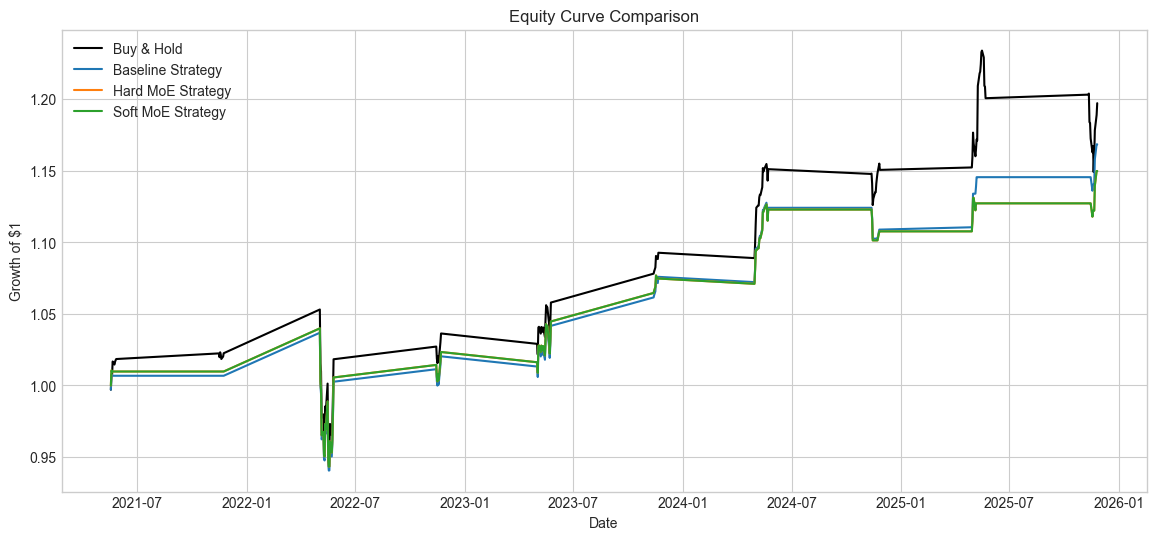

In [15]:
equity_df = predictions_df[["Date", target_col]].copy()

equity_df["buy_hold"] = (1 + equity_df[target_col]).cumprod()
equity_df["baseline_strategy"] = (1 + calculate_strategy_returns(equity_df[target_col], predictions_df["baseline_pred"])).cumprod()
equity_df["hard_moe_strategy"] = (1 + calculate_strategy_returns(equity_df[target_col], predictions_df["hard_moe_pred"])).cumprod()
equity_df["soft_moe_strategy"] = (1 + calculate_strategy_returns(equity_df[target_col], predictions_df["soft_moe_pred"])).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(equity_df["Date"], equity_df["buy_hold"], label="Buy & Hold", color="black")
plt.plot(equity_df["Date"], equity_df["baseline_strategy"], label="Baseline Strategy")
plt.plot(equity_df["Date"], equity_df["hard_moe_strategy"], label="Hard MoE Strategy")
plt.plot(equity_df["Date"], equity_df["soft_moe_strategy"], label="Soft MoE Strategy")
plt.title("Equity Curve Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

## 13. Interpret The Result

Use this cell to write your conclusion after seeing the metrics.

Good research conclusion format:

1. Did regime-aware modeling improve direction accuracy?
2. Did it improve Sharpe ratio?
3. Did it reduce max drawdown?
4. In which regimes did it work best or fail?

In [16]:
metrics_df

,model,rmse,mae,direction_accuracy,strategy_sharpe,strategy_max_drawdown,buy_hold_sharpe,buy_hold_max_drawdown
0,Baseline Random Forest,0.010911,0.007828,0.536,2.161004,-0.092875,2.250815,-0.092875
1,Hard-Routed MoE,0.011232,0.008100,0.512,1.942252,-0.092875,2.250815,-0.092875
2,Soft-Gated MoE,0.011232,0.008100,0.512,1.942252,-0.092875,2.250815,-0.092875


## Next Step

After this notebook works, the project can be upgraded in three ways:

1. Replace Random Forest with XGBoost or LightGBM.
2. Add walk-forward validation instead of one train/test split.
3. Add a neural gating network or transformer encoder.